In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Features
X = df.values

# Standardize data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

print(pca_df.head())

# Explained variance
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835
Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 0.9581320720000165


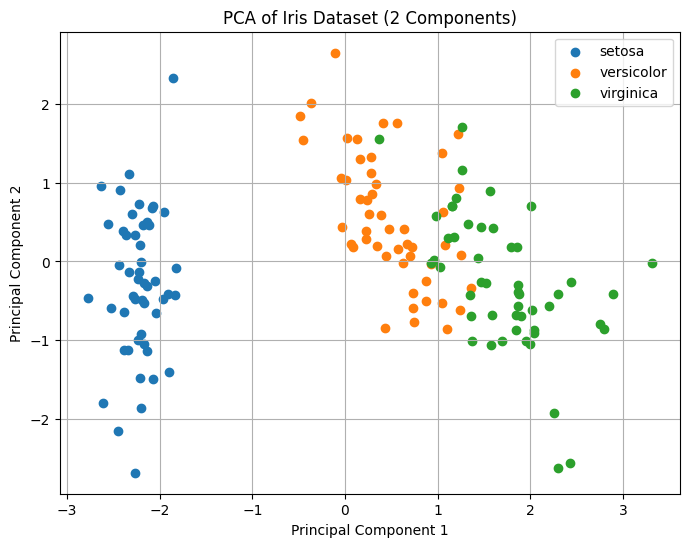

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# -------------------------
# 1. Load dataset
# -------------------------
iris = load_iris()
X = iris.data
y = iris.target
labels = iris.target_names

# -------------------------
# 2. Standardize data
# -------------------------
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

# -------------------------
# 3. Covariance matrix
# -------------------------
cov_matrix = np.cov(X_scaled.T)

# -------------------------
# 4. Eigen decomposition
# -------------------------
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# -------------------------
# 5. Sort eigenvalues (descending)
# -------------------------
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# -------------------------
# 6. Select top 2 components
# -------------------------
W = eigenvectors[:, :2]

# -------------------------
# 7. Project data
# -------------------------
X_pca = X_scaled @ W

# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["target"] = y

# -------------------------
# 8. Plot PCA result
# -------------------------
plt.figure(figsize=(8,6))

for i, label in enumerate(labels):
    plt.scatter(
        pca_df[pca_df["target"] == i]["PC1"],
        pca_df[pca_df["target"] == i]["PC2"],
        label=label
    )

plt.title("PCA of Iris Dataset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

Covariance Matrix:

[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]

Eigenvalues:

[2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors:

[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


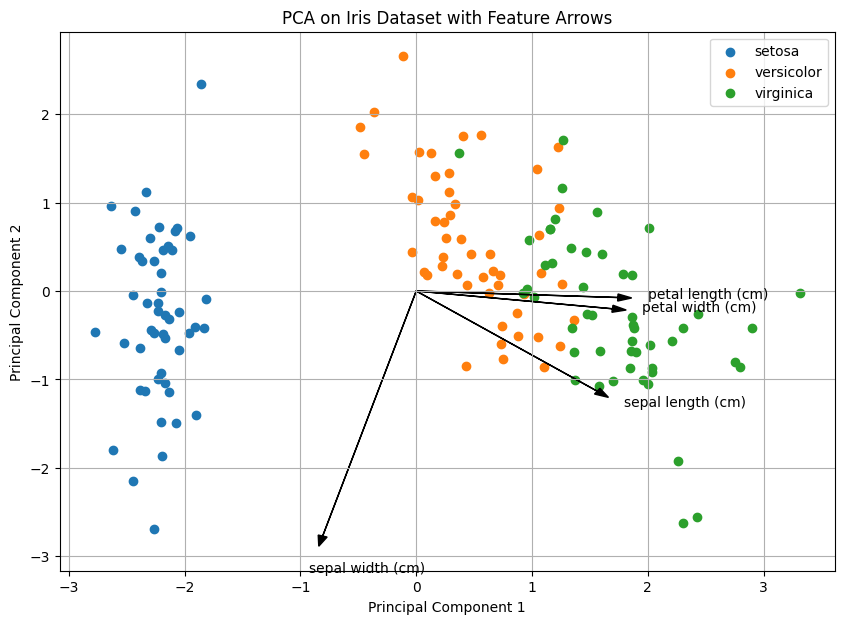


Explained Variance Ratio:

[0.72962445 0.22850762 0.03668922 0.00517871]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# STEP 1: Load Iris Dataset
# ------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

# ------------------------------------------
# STEP 2: Standardize the Data
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------
# STEP 3: Covariance Matrix
# ------------------------------------------

cov_matrix = np.cov(X_scaled.T)

print("Covariance Matrix:\n")
print(cov_matrix)

# ------------------------------------------
# STEP 4: Eigenvalues & Eigenvectors
# ------------------------------------------

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n")
print(eigenvalues)

print("\nEigenvectors:\n")
print(eigenvectors)

# ------------------------------------------
# STEP 5: Sort Eigenvalues
# ------------------------------------------

sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

# ------------------------------------------
# STEP 6: Select Top 2 Components
# ------------------------------------------

principal_components = sorted_eigenvectors[:, :2]

# ------------------------------------------
# STEP 7: Transform Data
# ------------------------------------------

X_pca = np.dot(X_scaled, principal_components)

# ------------------------------------------
# STEP 8: Create DataFrame
# ------------------------------------------

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Species"] = y

# ------------------------------------------
# STEP 9: Plot PCA
# ------------------------------------------

plt.figure(figsize=(10,7))

colors = ['red', 'green', 'blue']
labels = iris.target_names

for i in range(3):
    plt.scatter(
        pca_df.loc[pca_df["Species"] == i, "PC1"],
        pca_df.loc[pca_df["Species"] == i, "PC2"],
        label=labels[i]
    )

# ------------------------------------------
# STEP 10: Add Feature Arrows
# ------------------------------------------

# Scale arrows for visibility
arrow_size = 3

for i, feature in enumerate(feature_names):

    plt.arrow(
        0,                      # x start
        0,                      # y start
        principal_components[i, 0] * arrow_size,
        principal_components[i, 1] * arrow_size,
        color='black',
        head_width=0.08
    )

    plt.text(
        principal_components[i, 0] * arrow_size * 1.15,
        principal_components[i, 1] * arrow_size * 1.15,
        feature,
        color='black',
        fontsize=10
    )

# ------------------------------------------
# STEP 11: Labels and Title
# ------------------------------------------

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA on Iris Dataset with Feature Arrows")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------
# STEP 12: Explained Variance
# ------------------------------------------

explained_variance_ratio = (
    sorted_eigenvalues / np.sum(sorted_eigenvalues)
)

print("\nExplained Variance Ratio:\n")
print(explained_variance_ratio)


Covariance Matrix:

[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]

Eigenvalues:

[2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors:

[[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


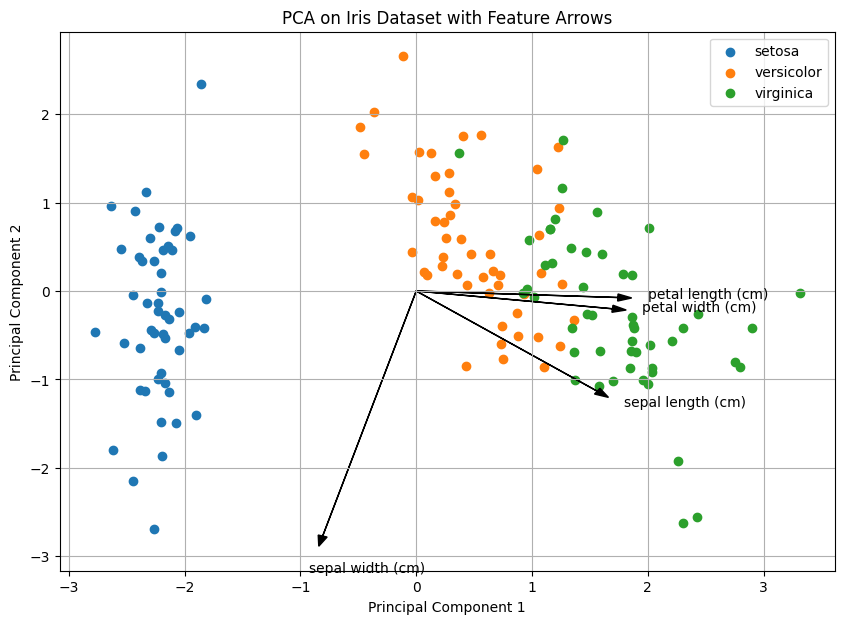


Explained Variance Ratio:

[0.72962445 0.22850762 0.03668922 0.00517871]


In [4]:

# ==========================================
# PCA WITH MANUAL CALCULATIONS + ARROWS
# IRIS DATASET
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# STEP 1: Load Iris Dataset
# ------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names

# ------------------------------------------
# STEP 2: Standardize the Data
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------
# STEP 3: Covariance Matrix
# ------------------------------------------

cov_matrix = np.cov(X_scaled.T)

print("Covariance Matrix:\n")
print(cov_matrix)

# ------------------------------------------
# STEP 4: Eigenvalues & Eigenvectors
# ------------------------------------------

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n")
print(eigenvalues)

print("\nEigenvectors:\n")
print(eigenvectors)

# ------------------------------------------
# STEP 5: Sort Eigenvalues
# ------------------------------------------

sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

# ------------------------------------------
# STEP 6: Select Top 2 Components
# ------------------------------------------

principal_components = sorted_eigenvectors[:, :2]

# ------------------------------------------
# STEP 7: Transform Data
# ------------------------------------------

X_pca = np.dot(X_scaled, principal_components)

# ------------------------------------------
# STEP 8: Create DataFrame
# ------------------------------------------

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Species"] = y

# ------------------------------------------
# STEP 9: Plot PCA
# ------------------------------------------

plt.figure(figsize=(10,7))

colors = ['red', 'green', 'blue']
labels = iris.target_names

for i in range(3):
    plt.scatter(
        pca_df.loc[pca_df["Species"] == i, "PC1"],
        pca_df.loc[pca_df["Species"] == i, "PC2"],
        label=labels[i]
    )

# ------------------------------------------
# STEP 10: Add Feature Arrows
# ------------------------------------------

# Scale arrows for visibility
arrow_size = 3

for i, feature in enumerate(feature_names):

    plt.arrow(
        0,                      # x start
        0,                      # y start
        principal_components[i, 0] * arrow_size,
        principal_components[i, 1] * arrow_size,
        color='black',
        head_width=0.08
    )

    plt.text(
        principal_components[i, 0] * arrow_size * 1.15,
        principal_components[i, 1] * arrow_size * 1.15,
        feature,
        color='black',
        fontsize=10
    )

# ------------------------------------------
# STEP 11: Labels and Title
# ------------------------------------------

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA on Iris Dataset with Feature Arrows")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------
# STEP 12: Explained Variance
# ------------------------------------------

explained_variance_ratio = (
    sorted_eigenvalues / np.sum(sorted_eigenvalues)
)

print("\nExplained Variance Ratio:\n")
print(explained_variance_ratio)

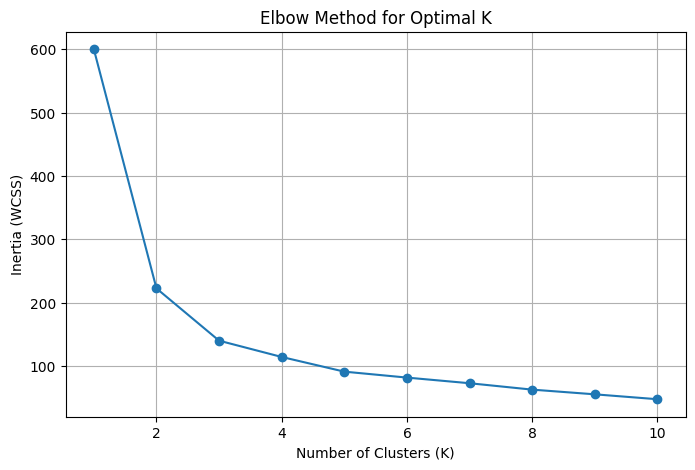

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load dataset
iris = load_iris()
X = iris.data

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow graph
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)

plt.show()

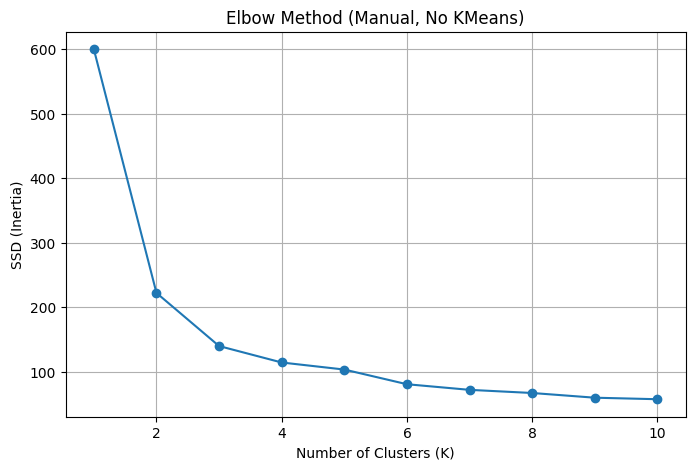

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
X = iris.data

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Function to compute SSD for a given k (manual clustering using random centers)
def compute_ssd(X, k, iterations=20):
    np.random.seed(42)
    
    # initialize random centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for _ in range(iterations):
        # compute distances
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        centroids = new_centroids
    
    # final SSD (inertia)
    distances = np.linalg.norm(X - centroids[labels], axis=1)
    return np.sum(distances ** 2)

# Elbow calculation
K_range = range(1, 11)
ssd_values = []

for k in K_range:
    ssd = compute_ssd(X, k)
    ssd_values.append(ssd)

# Plot
plt.figure(figsize=(8,5))
plt.plot(K_range, ssd_values, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSD (Inertia)")
plt.title("Elbow Method (Manual, No KMeans)")
plt.grid(True)

plt.show()

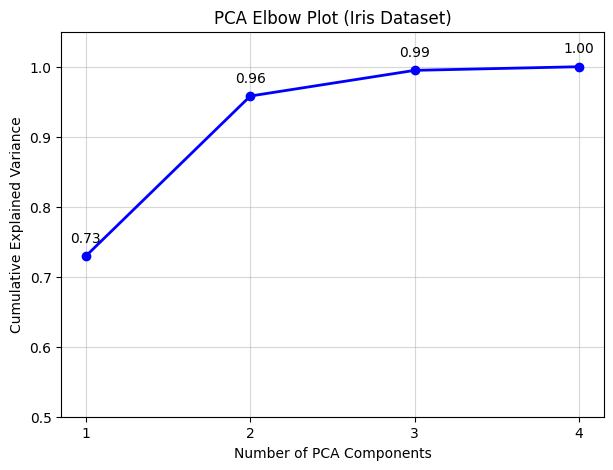

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
iris = load_iris()
X = iris.data
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=4)
pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(7,5))
plt.plot(range(1, 5),
         cumulative_variance,
         marker='o',
         linestyle='-',
         color='blue',
         linewidth=2)
for i, v in enumerate(cumulative_variance):
    plt.text(i+1, v+0.02, f"{v:.2f}", ha='center')

plt.xticks([1, 2, 3, 4])
plt.yticks(np.arange(0, 1.05, 0.1))
plt.ylim(0.5, 1.05)

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Elbow Plot (Iris Dataset)")
plt.grid(True, linestyle='-', alpha=0.5)

plt.show()